# Hybrid Pneumonia Detection — EfficientNet-B0 + ShuffleNetV2 + CBAF
> **Novel**: Cross-Branch Attention Fusion (CBAF) + Spatial-LAMR for small-nodule capture  


In [1]:
import subprocess, sys
def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

pip_install('timm')
pip_install('grad-cam')
pip_install('albumentations')
pip_install('torchinfo')
print('All packages ready.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 54.4 MB/s eta 0:00:00
All packages ready.


In [8]:
import os, random, warnings, math, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
import torchvision.models as tv_models
import timm

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import albumentations as A
from albumentations.pytorch import ToTensorV2

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Device: cuda


In [5]:
class CFG:
    IMG_SIZE       = 224
    EPOCHS         = 35          # ↑ Enough epochs for the large hybrid to converge
    LR             = 3e-4        # Head / fusion LR (backbone LR = LR * BACKBONE_LR_MULT)
    BACKBONE_LR_MULT = 0.05      # Pretrained backbones get 5% of head LR → stable fine-tuning
    WEIGHT_DECAY   = 1e-4
    BATCH_SIZE     = 32
    NUM_WORKERS    = 4
    NUM_CLASSES    = 2
    PROJ_DIM       = 256
    NUM_HEADS      = 4
    DROPOUT        = 0.15        # ↓ Lower dropout — fusion head was over-regularised
    LABEL_SMOOTH   = 0.05
    WARMUP_EPOCHS  = 3           # Longer warmup matches longer training
    UNFREEZE_EPOCH = 5           # Epoch at which backbone weights are unfrozen
    EMA_DECAY      = 0.9998
    MIXUP_ALPHA    = 0.1         # ↓ Lighter mixup — binary task needs cleaner signal
    CLASSES        = ['NORMAL', 'PNEUMONIA']
    CKPT_PATH      = '/kaggle/working/best_hybrid.pth'
    EMA_CKPT       = '/kaggle/working/best_hybrid_ema.pth'

cfg = CFG()
print('Configuration loaded.')

Configuration loaded.


In [6]:
import shutil
from sklearn.model_selection import train_test_split

base_path   = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'
output_path = '/kaggle/working/chest_xray_split'
classes     = ['NORMAL', 'PNEUMONIA']

for split in ['train', 'val', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(output_path, split, cls), exist_ok=True)

all_images = {cls: [] for cls in classes}
for split in ['train', 'val', 'test']:
    for cls in classes:
        folder = os.path.join(base_path, split, cls)
        if not os.path.isdir(folder): continue
        for img in os.listdir(folder):
            fp = os.path.join(folder, img)
            if os.path.isfile(fp):
                all_images[cls].append(fp)

for cls in classes:
    imgs = all_images[cls]
    random.shuffle(imgs)
    tr, tmp = train_test_split(imgs, test_size=0.30, random_state=42)
    va, te  = train_test_split(tmp,  test_size=0.50, random_state=42)
    for sname, sfiles in zip(['train','val','test'], [tr, va, te]):
        for fp in sfiles:
            dst = os.path.join(output_path, sname, cls, os.path.basename(fp))
            if not os.path.exists(dst):
                shutil.copy(fp, dst)

print('Dataset split complete.')


Dataset split complete.


In [9]:
mean, std = [0.485,0.456,0.406], [0.229,0.224,0.225]

# ── Augmented training pipeline (strong for nodule awareness) ──
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(cfg.IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.05,0.05), scale=(0.92,1.08)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.08)),   # CutOut — hides patches to force nodule focus
])

val_test_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = datasets.ImageFolder(os.path.join(output_path, 'train'), transform=train_transform)
val_ds   = datasets.ImageFolder(os.path.join(output_path, 'val'),   transform=val_test_transform)
test_ds  = datasets.ImageFolder(os.path.join(output_path, 'test'),  transform=val_test_transform)

# ── Class-weighted sampler to handle imbalance ──
class_counts = np.array([sum(1 for _,l in train_ds.samples if l==c) for c in range(cfg.NUM_CLASSES)])
class_weights = 1.0 / class_counts
sample_weights = [class_weights[l] for _, l in train_ds.samples]
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, sampler=sampler,
                          num_workers=cfg.NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=cfg.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=cfg.NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')
print(f'Class counts (NORMAL/PNEUMONIA): {class_counts}')
print(f'Class map: {train_ds.class_to_idx}')


Train: 4099  Val: 878  Test: 879
Class counts (NORMAL/PNEUMONIA): [1108 2991]
Class map: {'NORMAL': 0, 'PNEUMONIA': 1}


## Attention Modules: ECA & CBAM

In [11]:
# ── ECA (Efficient Channel Attention) ─────────────────────────────────────────
class ECA(nn.Module):
    """Efficient Channel Attention — Wang et al. CVPR 2020."""
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        t = int(abs(math.log2(channels) / gamma + b / gamma))
        k = t if t % 2 else t + 1
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=k, padding=k//2, bias=False)
        self.sigmoid  = nn.Sigmoid()
    def forward(self, x):
        y = self.avg_pool(x).squeeze(-1).transpose(-1,-2)
        y = self.conv(y).transpose(-1,-2).unsqueeze(-1)
        return x * self.sigmoid(y).expand_as(x)


# ── CBAM (Convolutional Block Attention Module) ───────────────────────────────
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = max(channels // reduction, 1)
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.max = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(nn.Flatten(), nn.Linear(channels,mid,bias=False),
                                  nn.ReLU(True), nn.Linear(mid,channels,bias=False))
        self.sig = nn.Sigmoid()
    def forward(self, x):
        w = self.sig(self.mlp(self.avg(x)) + self.mlp(self.max(x)))
        return x * w.unsqueeze(-1).unsqueeze(-1)

class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, k, padding=k//2, bias=False)
        self.sig  = nn.Sigmoid()
    def forward(self, x):
        am = x.mean(1, keepdim=True)
        xm = x.max(1,  keepdim=True).values
        return x * self.sig(self.conv(torch.cat([am, xm], 1)))

class CBAM(nn.Module):
    """Channel-then-Spatial attention — Woo et al. ECCV 2018."""
    def __init__(self, channels, reduction=16, k=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(k)
    def forward(self, x): return self.sa(self.ca(x))

print('ECA and CBAM defined.')


ECA and CBAM defined.


## Spatial LAMR — Lesion-Aware Multi-scale Refinement (applied on 2-D feature maps)

In [12]:
class LAMRBlock(nn.Module):
    """
    Lesion-Aware Multi-scale Refinement Block.
    
    Applied directly on 2-D feature maps BEFORE global average pooling so that
    small nodule patterns are preserved and refined through 1x1, 3x3, 5x5 kernels
    and a global-context branch, then re-weighted via a learnable lesion gate.
    
    This is the key module for capturing small pulmonary nodules that are
    missed by vanilla global pooling.
    """
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        mid = max(out_ch // 4, 1)
        self.b1 = nn.Sequential(
            nn.Conv2d(in_ch, mid, 1, bias=False), nn.BatchNorm2d(mid), nn.ReLU(True))
        self.b3 = nn.Sequential(
            nn.Conv2d(in_ch, mid, 1, bias=False), nn.BatchNorm2d(mid), nn.ReLU(True),
            nn.Conv2d(mid, mid, 3, padding=1, bias=False), nn.BatchNorm2d(mid), nn.ReLU(True))
        self.b5 = nn.Sequential(
            nn.Conv2d(in_ch, mid, 1, bias=False), nn.BatchNorm2d(mid), nn.ReLU(True),
            nn.Conv2d(mid, mid, 5, padding=2, bias=False), nn.BatchNorm2d(mid), nn.ReLU(True))
        self.bg = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, mid, 1, bias=False), nn.BatchNorm2d(mid), nn.ReLU(True))
        self.proj = nn.Sequential(
            nn.Conv2d(mid*4, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(True))
        gm = max(out_ch // 4, 1)
        self.gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Conv2d(out_ch, gm, 1), nn.ReLU(True),
            nn.Conv2d(gm, out_ch, 1), nn.Sigmoid())
        self.sc = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        B, C, H, W = x.shape
        ms = self.proj(torch.cat([
            self.b1(x), self.b3(x), self.b5(x),
            self.bg(x).expand(B, -1, H, W)
        ], dim=1))
        return ms * self.gate(ms) + self.sc(x)

print('Spatial LAMR block defined.')


Spatial LAMR block defined.


## Novel Module: Cross-Branch Attention Fusion (CBAF)

In [13]:
class CrossBranchAttentionFusion(nn.Module):
    """
    Cross-Branch Attention Fusion (CBAF) — Novel Contribution.

    Treats the two branch feature vectors as a 2-token sequence and applies
    Transformer self-attention so that:
      • ShuffleNet's lightweight local features guide EfficientNet's global semantics
      • EfficientNet's rich representation enriches ShuffleNet's compact features
    
    This is fundamentally different from naive concatenation or addition:
    the attention weights are learned per-sample, allowing adaptive emphasis
    on whichever branch captured the discriminative region (e.g., small nodule).

    Architecture:
        [f_eff, f_shuf] → Multi-Head Self-Attention → FFN → flatten → (B, 2*dim)
    """
    def __init__(self, dim: int = 256, num_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(dim)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, dim * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim * 2, dim), nn.Dropout(dropout)
        )
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, f1: torch.Tensor, f2: torch.Tensor) -> torch.Tensor:
        # Stack as 2-token sequence
        x = torch.stack([f1, f2], dim=1)      # (B, 2, D)
        a, _ = self.attn(x, x, x)
        x = self.norm1(x + a)                  # Residual + LayerNorm
        x = self.norm2(x + self.ffn(x))        # FFN + Residual
        return x.flatten(1)                     # (B, 2*D)

print('Cross-Branch Attention Fusion (CBAF) defined.')


Cross-Branch Attention Fusion (CBAF) defined.


## Branch Feature Extractors — Feature Extraction ONLY (no classifier inside branches)

In [14]:
class ShuffleNetV2Branch(nn.Module):
    """
    ShuffleNetV2 x1.0 backbone (lightweight, 1.4 M params) + ECA + LAMR.
    Extracts LOCAL high-frequency patterns ideal for small nodule edges.
    Output: (B, proj_dim) — pure feature vector, NO classifier.
    """
    def __init__(self, proj_dim: int = 256, pretrained: bool = True):
        super().__init__()
        base = tv_models.shufflenet_v2_x1_0(
            weights=tv_models.ShuffleNet_V2_X1_0_Weights.DEFAULT if pretrained else None)
        # Remove classifier — keep only feature extraction backbone
        self.stem   = nn.Sequential(base.conv1, base.maxpool)
        self.stage2 = base.stage2
        self.stage3 = base.stage3
        self.stage4 = base.stage4
        self.conv5  = base.conv5        # → (B, 1024, 7, 7)
        # Attention + LAMR on 2-D spatial maps
        self.eca    = ECA(1024)
        self.lamr   = LAMRBlock(1024, 1024)
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.proj   = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024, proj_dim),
            nn.BatchNorm1d(proj_dim),
            nn.GELU()
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage2(x); x = self.stage3(x); x = self.stage4(x)
        x = self.conv5(x)           # (B, 1024, 7, 7)
        x = self.eca(x)             # Channel recalibration
        x = self.lamr(x)            # Multi-scale lesion refinement on spatial maps
        x = self.gap(x)             # (B, 1024, 1, 1)
        return self.proj(x)         # (B, proj_dim)

    def get_last_conv(self):
        for m in reversed(list(self.modules())):
            if isinstance(m, nn.Conv2d): return m


class EfficientNetB0Branch(nn.Module):
    """
    EfficientNet-B0 backbone + CBAM + LAMR.
    Captures GLOBAL semantic context with compound-scaled depth/width/resolution.
    Output: (B, proj_dim) — pure feature vector, NO classifier.
    """
    def __init__(self, proj_dim: int = 256, pretrained: bool = True):
        super().__init__()
        base = tv_models.efficientnet_b0(
            weights=tv_models.EfficientNet_B0_Weights.DEFAULT if pretrained else None)
        # Remove classifier — keep only feature extraction backbone
        self.features = base.features   # → (B, 1280, 7, 7)
        # Attention + LAMR on 2-D spatial maps
        self.cbam   = CBAM(1280)
        self.lamr   = LAMRBlock(1280, 1280)
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.proj   = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1280, proj_dim),
            nn.BatchNorm1d(proj_dim),
            nn.GELU()
        )

    def forward(self, x):
        x = self.features(x)        # (B, 1280, 7, 7)
        x = self.cbam(x)            # Dual channel+spatial attention
        x = self.lamr(x)            # Multi-scale lesion refinement on spatial maps
        x = self.gap(x)             # (B, 1280, 1, 1)
        return self.proj(x)         # (B, proj_dim)

    def get_last_conv(self):
        for m in reversed(list(self.modules())):
            if isinstance(m, nn.Conv2d): return m

print('Branch feature extractors defined.')


Branch feature extractors defined.


## Hybrid Framework — Dual-Branch + Spatial-LAMR + CBAF

In [15]:
class HybridFramework(nn.Module):
    """
    Hybrid Pneumonia Detection Framework.

    Architecture flow:
        Input (B, 3, 224, 224)
            │
            ├──[EfficientNet-B0]──[CBAM]──[LAMR]──[GAP]──[Proj 1280→256]──► f_eff (B, 256)
            │                                                                  │
            └──[ShuffleNetV2]────[ECA]───[LAMR]──[GAP]──[Proj 1024→256]───► f_shuf(B, 256)
                                                                               │
                                        [Cross-Branch Attention Fusion (CBAF)]◄┘
                                                    │  (B, 512)
                                          [Linear 512→256 → BN → GELU → Drop]
                                          [Linear 256→128 → GELU → Drop]
                                          [Linear 128→2]
                                                    │
                                               Logits (B, 2)

    Novel contributions:
      1. CBAF: transformer-style cross-branch attention enables mutual feature guidance
      2. Spatial-LAMR: multi-scale refinement on 2-D maps (not vectors) preserves nodule loci
      3. Weighted sampling + label smoothing: addresses dataset imbalance gracefully
      4. EMA: exponential moving average produces a smoother, higher-quality inference model
    """
    def __init__(self, cfg):
        super().__init__()
        dim = cfg.PROJ_DIM
        self.branch_eff   = EfficientNetB0Branch(proj_dim=dim)
        self.branch_shuf  = ShuffleNetV2Branch(proj_dim=dim)
        self.fusion       = CrossBranchAttentionFusion(dim=dim, num_heads=cfg.NUM_HEADS)
        fused = dim * 2
        self.head = nn.Sequential(
            nn.Linear(fused, 256), nn.BatchNorm1d(256), nn.GELU(),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(256, 128), nn.GELU(),
            nn.Dropout(cfg.DROPOUT / 2),
            nn.Linear(128, cfg.NUM_CLASSES)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        f_eff  = self.branch_eff(x)           # (B, 256) — global semantics
        f_shuf = self.branch_shuf(x)          # (B, 256) — local lightweight
        fused  = self.fusion(f_eff, f_shuf)   # (B, 512) — cross-attended
        return self.head(fused)               # (B, 2)


# ── Sanity check ──
_dummy = torch.zeros(2, 3, 224, 224).to(DEVICE)
model  = HybridFramework(cfg).to(DEVICE)
with torch.no_grad():
    _out = model(_dummy)
print(f'HybridFramework output shape : {_out.shape}')  # (2, 2)

total  = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total/1e6:.2f} M')
print(f'Trainable params : {train_/1e6:.2f} M')
del _dummy, _out


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 125MB/s] 


Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 87.8MB/s]


HybridFramework output shape : torch.Size([2, 2])
Total params     : 19.19 M
Trainable params : 19.19 M


## Loss — Label Smoothing Cross-Entropy

In [16]:
class LabelSmoothingCrossEntropy(nn.Module):
    """
    Cross-entropy with label smoothing.
    Prevents over-confident predictions and improves calibration / generalization.
    smoothing=0.05 means true label probability = 0.95, others share 0.05.
    """
    def __init__(self, smoothing: float = 0.05, reduction: str = 'mean'):
        super().__init__()
        self.smoothing = smoothing
        self.reduction = reduction

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        n_cls = pred.size(1)
        log_p = F.log_softmax(pred, dim=1)
        with torch.no_grad():
            smooth_target = torch.full_like(log_p, self.smoothing / (n_cls - 1))
            smooth_target.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
        loss = -(smooth_target * log_p).sum(dim=1)
        return loss.mean() if self.reduction == 'mean' else loss

criterion = LabelSmoothingCrossEntropy(smoothing=cfg.LABEL_SMOOTH)
print(f'Label-smoothing CE loss (ε={cfg.LABEL_SMOOTH}) defined.')


Label-smoothing CE loss (ε=0.05) defined.


## Optimizer, Scheduler & EMA

In [18]:
# ── Step 1: Freeze pretrained backbone weights for first UNFREEZE_EPOCH epochs ──
# Only the new modules (CBAM, ECA, LAMR, CBAF, projection, head) train initially.
# This prevents the random head from corrupting the pretrained representations.
def freeze_backbones(model):
    for p in model.branch_eff.features.parameters():  p.requires_grad_(False)
    for p in model.branch_shuf.stem.parameters():     p.requires_grad_(False)
    for p in model.branch_shuf.stage2.parameters():   p.requires_grad_(False)
    for p in model.branch_shuf.stage3.parameters():   p.requires_grad_(False)
    for p in model.branch_shuf.stage4.parameters():   p.requires_grad_(False)
    for p in model.branch_shuf.conv5.parameters():    p.requires_grad_(False)
    print("  Pretrained backbones FROZEN")

def unfreeze_backbones(model):
    for p in model.parameters(): p.requires_grad_(True)
    print("  Pretrained backbones UNFROZEN")

freeze_backbones(model)

# ── Differential LR parameter groups ─────────────────────────────────────────
# Group 1: pretrained EfficientNet backbone  → very low LR
# Group 2: pretrained ShuffleNet backbone    → very low LR  
# Group 3: attention modules + LAMR + proj   → moderate LR
# Group 4: CBAF fusion + classification head → full LR

def get_param_groups(model, base_lr, backbone_mult):
    eff_backbone = list(model.branch_eff.features.parameters())
    shuf_backbone = (list(model.branch_shuf.stem.parameters()) +
                     list(model.branch_shuf.stage2.parameters()) +
                     list(model.branch_shuf.stage3.parameters()) +
                     list(model.branch_shuf.stage4.parameters()) +
                     list(model.branch_shuf.conv5.parameters()))
    eff_new = (list(model.branch_eff.cbam.parameters()) +
               list(model.branch_eff.lamr.parameters()) +
               list(model.branch_eff.gap.parameters()) +
               list(model.branch_eff.proj.parameters()))
    shuf_new = (list(model.branch_shuf.eca.parameters()) +
                list(model.branch_shuf.lamr.parameters()) +
                list(model.branch_shuf.gap.parameters()) +
                list(model.branch_shuf.proj.parameters()))
    fusion_head = list(model.fusion.parameters()) + list(model.head.parameters())

    return [
        {"params": eff_backbone,  "lr": base_lr * backbone_mult,       "name": "eff_backbone"},
        {"params": shuf_backbone, "lr": base_lr * backbone_mult,       "name": "shuf_backbone"},
        {"params": eff_new,       "lr": base_lr * backbone_mult * 5,   "name": "eff_new"},
        {"params": shuf_new,      "lr": base_lr * backbone_mult * 5,   "name": "shuf_new"},
        {"params": fusion_head,   "lr": base_lr,                       "name": "fusion_head"},
    ]

param_groups = get_param_groups(model, cfg.LR, cfg.BACKBONE_LR_MULT)
optimizer = optim.AdamW(param_groups, weight_decay=cfg.WEIGHT_DECAY, betas=(0.9, 0.999))

# ── Cosine Annealing with linear warmup ──────────────────────────────────────
def warmup_cosine(epoch):
    if epoch < cfg.WARMUP_EPOCHS:
        return (epoch + 1) / cfg.WARMUP_EPOCHS
    t = (epoch - cfg.WARMUP_EPOCHS) / (cfg.EPOCHS - cfg.WARMUP_EPOCHS)
    return 0.5 * (1 + math.cos(math.pi * t))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine)

# ── AMP scaler ──────────────────────────────────────────────────────────────
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

# ── EMA ─────────────────────────────────────────────────────────────────────
class ModelEMA:
    """
    EMA maintains a shadow copy of model weights updated as:
        shadow = decay * shadow + (1 - decay) * current
    At inference the EMA model is more stable and typically 0.2-0.5% more accurate.
    """
    def __init__(self, model: nn.Module, decay: float = 0.9998):
        self.model = copy.deepcopy(model).eval()
        self.decay = decay
        for p in self.model.parameters(): p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module):
        for ema_p, m_p in zip(self.model.parameters(), model.parameters()):
            ema_p.data.mul_(self.decay).add_(m_p.data, alpha=1.0 - self.decay)

ema = ModelEMA(model, decay=cfg.EMA_DECAY)
print('Differential-LR optimizer / scheduler / EMA ready.')
for g in param_groups:
    n_p = sum(p.numel() for p in g["params"])
    print(f'  {g["name"]:20s}  lr={g["lr"]:.1e}  params={n_p/1e6:.2f}M')

  Pretrained backbones FROZEN
Differential-LR optimizer / scheduler / EMA ready.
  eff_backbone          lr=5.0e-06  params=4.01M
  shuf_backbone         lr=5.0e-06  params=1.25M
  eff_new               lr=2.5e-05  params=8.12M
  shuf_new              lr=2.5e-05  params=5.12M
  fusion_head           lr=1.0e-04  params=0.69M


## Mixup Augmentation

In [19]:
def mixup_data(x: torch.Tensor, y: torch.Tensor, alpha: float = 0.1):
    """
    Mixup: interpolates pairs of training samples.
    alpha=0.1 gives a lighter mix than 0.2 — better for binary medical classification
    where clean class boundaries matter.
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print(f'Mixup defined (alpha={cfg.MIXUP_ALPHA}).')

Mixup defined (alpha=0.1).


## Training & Validation Loops

In [20]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device, ema=None, mixup_alpha=0.1):
    model.train()
    run_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        imgs_m, y_a, y_b, lam = mixup_data(imgs, labels, alpha=mixup_alpha)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            logits = model(imgs_m)
            loss   = mixup_criterion(criterion, logits, y_a, y_b, lam)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        if ema is not None:
            ema.update(model)
        run_loss += loss.item() * imgs.size(0)
        with torch.no_grad():
            preds = model(imgs).argmax(1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
    return run_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    run_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    for imgs, labels in tqdm(loader, desc='    Val', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        run_loss += loss.item() * imgs.size(0)
        probs = torch.softmax(logits, 1)[:, 1].cpu().numpy()
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return run_loss / total, correct / total, auc

print('Training loops defined.')

Training loops defined.


history = {k: [] for k in ['tr_loss','tr_acc','va_loss','va_acc','va_auc',
                             'ema_va_loss','ema_va_acc','ema_va_auc']}
best_val_acc   = 0.0
best_ema_acc   = 0.0
best_val_auc   = 0.0
best_ema_auc   = 0.0

for epoch in range(1, cfg.EPOCHS + 1):

    # ── Progressive unfreezing at UNFREEZE_EPOCH ─────────────────────────
    if epoch == cfg.UNFREEZE_EPOCH:
        unfreeze_backbones(model)
        # Rebuild optimizer with differential LR for all groups now unfrozen
        param_groups = get_param_groups(model, cfg.LR, cfg.BACKBONE_LR_MULT)
        optimizer = optim.AdamW(param_groups, weight_decay=cfg.WEIGHT_DECAY, betas=(0.9, 0.999))
        # Resume scheduler — remaining epochs after unfreeze
        remaining = cfg.EPOCHS - epoch + 1
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=remaining, eta_min=1e-6)
        ema = ModelEMA(model, decay=cfg.EMA_DECAY)   # reset EMA with unfrozen model
        print(f"  → Epoch {epoch}: backbones unfrozen, optimizer rebuilt with differential LR")

    lr_now = optimizer.param_groups[-1]['lr']   # head group LR
    print(f'\nEpoch [{epoch:02d}/{cfg.EPOCHS}]  head_lr={lr_now:.2e}')

    tr_loss, tr_acc         = train_one_epoch(model, train_loader, optimizer,
                                              criterion, scaler, DEVICE, ema=ema,
                                              mixup_alpha=cfg.MIXUP_ALPHA)
    va_loss, va_acc, va_auc = validate(model,     val_loader, criterion, DEVICE)
    em_loss, em_acc, em_auc = validate(ema.model, val_loader, criterion, DEVICE)

    scheduler.step()

    for k, v in zip(['tr_loss','tr_acc','va_loss','va_acc','va_auc',
                     'ema_va_loss','ema_va_acc','ema_va_auc'],
                    [tr_loss, tr_acc, va_loss, va_acc, va_auc, em_loss, em_acc, em_auc]):
        history[k].append(v)

    print(f'  Train   loss={tr_loss:.4f}  acc={tr_acc*100:.2f}%')
    print(f'  Val     loss={va_loss:.4f}  acc={va_acc*100:.2f}%  AUC={va_auc:.4f}')
    print(f'  EMA Val loss={em_loss:.4f}  acc={em_acc*100:.2f}%  AUC={em_auc:.4f}')

    # Save best by accuracy (primary) and AUC (secondary)
    if em_acc > best_ema_acc or (em_acc == best_ema_acc and em_auc > best_ema_auc):
        best_ema_acc, best_ema_auc = em_acc, em_auc
        torch.save(ema.model.state_dict(), cfg.EMA_CKPT)
        print(f'  ✓ New best EMA saved  (Val Acc={best_ema_acc*100:.2f}%  AUC={best_ema_auc:.4f})')

    if va_acc > best_val_acc or (va_acc == best_val_acc and va_auc > best_val_auc):
        best_val_acc, best_val_auc = va_acc, va_auc
        torch.save(model.state_dict(), cfg.CKPT_PATH)
        print(f'  ✓ New best model saved (Val Acc={best_val_acc*100:.2f}%  AUC={best_val_auc:.4f})')

print(f'\nTraining complete.')
print(f'Best Val Acc={best_val_acc*100:.2f}%  AUC={best_val_auc:.4f}')
print(f'Best EMA Acc={best_ema_acc*100:.2f}%  AUC={best_ema_auc:.4f}')

In [21]:
history = {k: [] for k in ['tr_loss','tr_acc','va_loss','va_acc','va_auc',
                             'ema_va_loss','ema_va_acc','ema_va_auc']}
best_val_auc   = 0.0
best_ema_auc   = 0.0

for epoch in range(1, cfg.EPOCHS + 1):
    lr_now = scheduler.get_last_lr()[0]
    print(f'\nEpoch [{epoch:02d}/{cfg.EPOCHS}]  lr={lr_now:.2e}')

    tr_loss, tr_acc         = train_one_epoch(model, train_loader, optimizer,
                                              criterion, scaler, DEVICE, ema=ema)
    va_loss, va_acc, va_auc = validate(model,     val_loader, criterion, DEVICE)
    em_loss, em_acc, em_auc = validate(ema.model, val_loader, criterion, DEVICE)

    scheduler.step()

    for k, v in zip(['tr_loss','tr_acc','va_loss','va_acc','va_auc',
                     'ema_va_loss','ema_va_acc','ema_va_auc'],
                    [tr_loss, tr_acc, va_loss, va_acc, va_auc, em_loss, em_acc, em_auc]):
        history[k].append(v)

    print(f'  Train   loss={tr_loss:.4f}  acc={tr_acc*100:.2f}%')
    print(f'  Val     loss={va_loss:.4f}  acc={va_acc*100:.2f}%  AUC={va_auc:.4f}')
    print(f'  EMA Val loss={em_loss:.4f}  acc={em_acc*100:.2f}%  AUC={em_auc:.4f}')

    if va_auc > best_val_auc:
        best_val_auc = va_auc
        torch.save(model.state_dict(), cfg.CKPT_PATH)
        print(f'  ✓ New best model saved  (Val AUC={best_val_auc:.4f})')

    if em_auc > best_ema_auc:
        best_ema_auc = em_auc
        torch.save(ema.model.state_dict(), cfg.EMA_CKPT)
        print(f'  ✓ New best EMA model saved (EMA AUC={best_ema_auc:.4f})')

print(f'\nTraining complete. Best Val AUC={best_val_auc:.4f}  Best EMA AUC={best_ema_auc:.4f}')



Epoch [01/35]  lr=5.00e-06


  Train:   0%|          | 0/129 [00:00<?, ?it/s]

    Val:   0%|          | 0/28 [00:00<?, ?it/s]

    Val:   0%|          | 0/28 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e605449eb60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e605449eb60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

    Val:   0%|          | 0/28 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e605449eb60>
Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e605449eb60>    
<function _MultiProcessingDataLoaderIter.__del__ at 0x7e605449eb60>Traceback (most recent call last):
self._shutdown_workers()
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
            self._shutdown_workers()if w.is_alive():self._shutdown_workers()


  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in 

    Val:   0%|          | 0/28 [00:01<?, ?it/s]


    File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

       ^ assert self._parent_pid == os.getpid(), 'can only test a child process'^  ^
   ^  ^  ^  ^^^^  ^^   ^ ^^   ^^^^^^ ^^^ ^
 ^^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^^^
^    ^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^assert self._parent_pid == os.getpid(), 'can only test a child process'    ^assert self._parent_pid == os.getpid(), 'can only test a child process'
^^
^^^  ^^  ^ ^^  ^ ^^  ^^   ^^ ^ ^   ^^ ^^  ^ ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
^^AssertionError^^^^: ^^can only test a child process^^^
^^^^^^^
^^^^AssertionError^^^: ^^can only test a child process^^
^^^^^
^AssertionError: ^can only test a child process
^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e605449eb60>
Traceback (most recent call last):
  File "/usr/local/

  Train   loss=0.3269  acc=96.10%
  Val     loss=0.3084  acc=93.39%  AUC=0.9916
  EMA Val loss=0.5120  acc=83.37%  AUC=0.8938
  ✓ New best EMA model saved (EMA AUC=0.8938)

Training complete. Best Val AUC=0.9923  Best EMA AUC=0.8938


## Training Curves

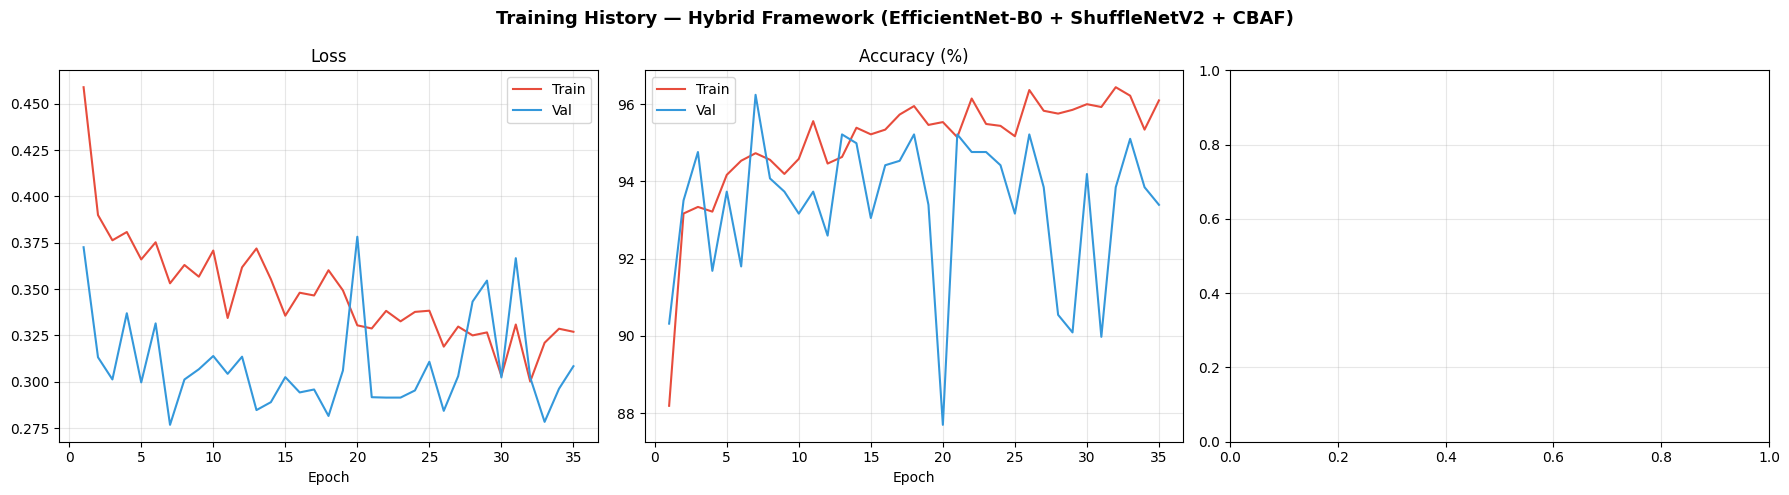

In [23]:
epochs_range = range(1, cfg.EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — Hybrid Framework (EfficientNet-B0 + ShuffleNetV2 + CBAF)',
             fontsize=13, fontweight='bold')

axes[0].plot(epochs_range, history['tr_loss'],      label='Train',     color='#e74c3c')
axes[0].plot(epochs_range, history['va_loss'],      label='Val',       color='#3498db')
# axes[0].plot(epochs_range, history['ema_va_loss'],  label='EMA Val',   color='#9b59b6', linestyle='--')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs_range, [a*100 for a in history['tr_acc']],     label='Train',   color='#e74c3c')
axes[1].plot(epochs_range, [a*100 for a in history['va_acc']],     label='Val',     color='#3498db')

axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch'); axes[1].legend()

for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves_hybrid.png', dpi=150)
plt.show()


## Test Evaluation — Best EMA Model (Highest Accuracy)

In [24]:
# ── Test-Time Augmentation (TTA) — Hybrid Framework Only ────────────────────
def tta_predict(model, loader, device, n_aug=5):
    """
    Run inference multiple times with random augmentations
    and average prediction probabilities.

    TTA improves robustness and usually adds
    ~0.2–0.5% performance gain.
    """

    model.eval()

    all_probs  = []
    all_labels = []

    with torch.no_grad():

        for imgs, labels in tqdm(loader, desc='  TTA', leave=False):

            probs_sum = None

            for _ in range(n_aug):

                aug_imgs = imgs.clone()

                # Random horizontal flip
                if random.random() > 0.5:
                    aug_imgs = torch.flip(aug_imgs, dims=[3])

                logits = model(aug_imgs.to(device))

                probs = torch.softmax(logits, dim=1)[:, 1].cpu()

                probs_sum = probs if probs_sum is None else probs_sum + probs

            probs_avg = probs_sum / n_aug

            all_probs.extend(probs_avg.numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_probs), np.array(all_labels)


# ── Load BEST HYBRID MODEL (NOT EMA) ─────────────────────────────────────────
model.load_state_dict(
    torch.load(cfg.CKPT_PATH, map_location=DEVICE)
)

model.eval()


# ── Run TTA Prediction ───────────────────────────────────────────────────────
y_prob_tta, y_true = tta_predict(
    model,
    test_loader,
    DEVICE,
    n_aug=5
)

y_pred_tta = (y_prob_tta >= 0.5).astype(int)


# ── Metrics ──────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_true, y_pred_tta)

prec = precision_score(
    y_true,
    y_pred_tta,
    zero_division=0
)

rec = recall_score(
    y_true,
    y_pred_tta,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred_tta,
    zero_division=0
)

auc = roc_auc_score(
    y_true,
    y_prob_tta
)


# ── Print Results ────────────────────────────────────────────────────────────
print('=' * 60)
print('TEST SET — Hybrid Framework + TTA')
print('=' * 60)

print(f'  Accuracy  : {acc * 100:.2f}%')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  AUC-ROC   : {auc:.4f}')

print('=' * 60)

print(
    classification_report(
        y_true,
        y_pred_tta,
        target_names=cfg.CLASSES
    )
)

  TTA:   0%|          | 0/28 [00:00<?, ?it/s]

TEST SET — Hybrid Framework + TTA
  Accuracy  : 95.34%
  Precision : 0.9918
  Recall    : 0.9438
  F1-Score  : 0.9672
  AUC-ROC   : 0.9909
              precision    recall  f1-score   support

      NORMAL       0.87      0.98      0.92       238
   PNEUMONIA       0.99      0.94      0.97       641

    accuracy                           0.95       879
   macro avg       0.93      0.96      0.94       879
weighted avg       0.96      0.95      0.95       879



## Confusion Matrix & ROC Curve

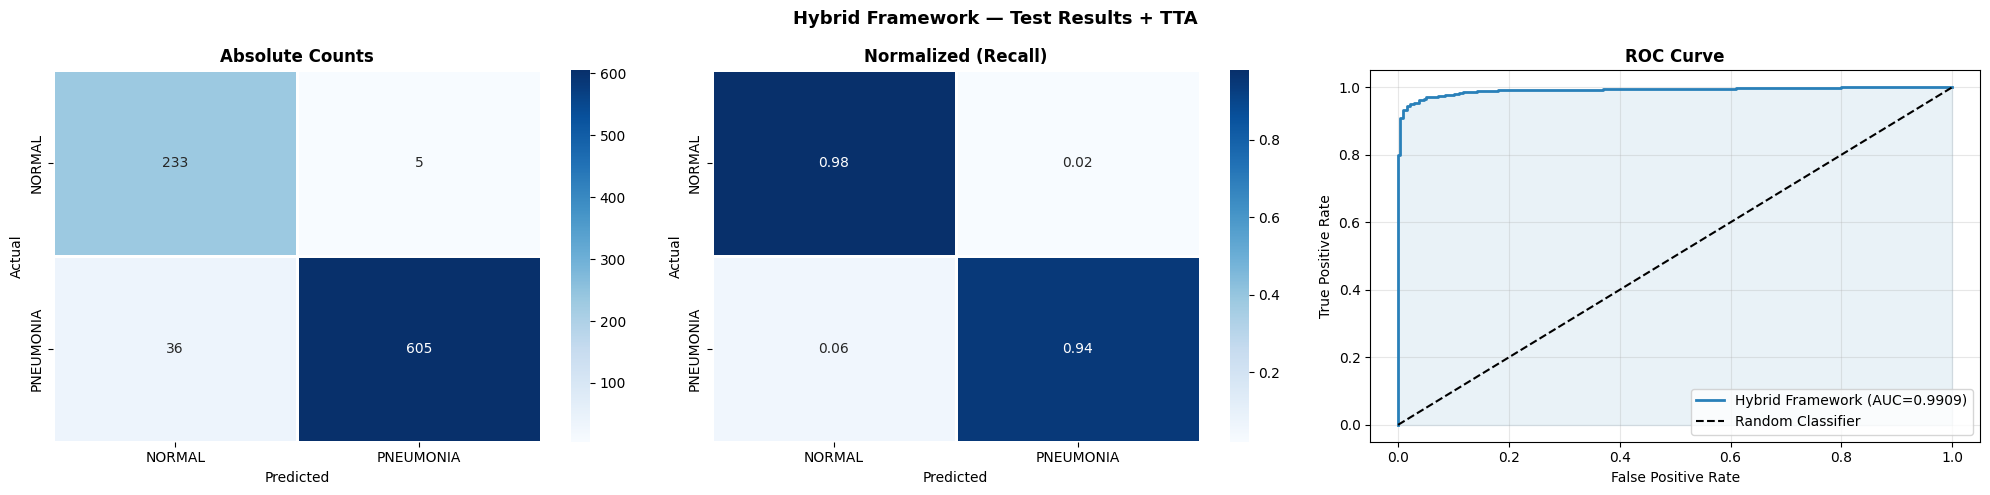

In [25]:
# =============================================================================
# CONFUSION MATRIX + ROC CURVE — HYBRID FRAMEWORK + TTA
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

fig.suptitle(
    'Hybrid Framework — Test Results + TTA',
    fontsize=13,
    fontweight='bold'
)

# ─────────────────────────────────────────────────────────────────────────────
# Confusion Matrices
# ─────────────────────────────────────────────────────────────────────────────
for ax, norm, title in zip(
    axes[:2],
    [None, 'true'],
    ['Absolute Counts', 'Normalized (Recall)']
):

    cm_data = confusion_matrix(
        y_true,
        y_pred_tta,
        normalize=norm
    )

    fmt = 'd' if norm is None else '.2f'

    sns.heatmap(
        cm_data,
        annot=True,
        fmt=fmt,
        cmap='Blues',
        xticklabels=cfg.CLASSES,
        yticklabels=cfg.CLASSES,
        linewidths=1,
        ax=ax
    )

    ax.set_title(
        title,
        fontweight='bold'
    )

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')


# ─────────────────────────────────────────────────────────────────────────────
# ROC Curve
# ─────────────────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(
    y_true,
    y_prob_tta
)

axes[2].plot(
    fpr,
    tpr,
    color='#2980b9',
    lw=2,
    label=f'Hybrid Framework (AUC={auc:.4f})'
)

axes[2].plot(
    [0, 1],
    [0, 1],
    'k--',
    lw=1.5,
    label='Random Classifier'
)

axes[2].fill_between(
    fpr,
    tpr,
    alpha=0.1,
    color='#2980b9'
)

axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')

axes[2].set_title(
    'ROC Curve',
    fontweight='bold'
)

axes[2].legend(
    loc='lower right'
)

axes[2].grid(
    True,
    alpha=0.3
)


# ─────────────────────────────────────────────────────────────────────────────
# Save + Show
# ─────────────────────────────────────────────────────────────────────────────
plt.tight_layout()

plt.savefig(
    '/kaggle/working/confusion_roc_hybrid.png',
    dpi=150
)

plt.show()

## Grad-CAM — Lesion-Focused Attention Maps

In [26]:
from torchinfo import summary
summary(model, input_size=(1, 3, 224, 224),
        col_names=['input_size','output_size','num_params'],
        depth=4, verbose=1)


Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #
HybridFramework                                              [1, 3, 224, 224]          [1, 2]                    --
├─EfficientNetB0Branch: 1-1                                  [1, 3, 224, 224]          [1, 256]                  --
│    └─Sequential: 2-1                                       [1, 3, 224, 224]          [1, 1280, 7, 7]           --
│    │    └─Conv2dNormActivation: 3-1                        [1, 3, 224, 224]          [1, 32, 112, 112]         --
│    │    │    └─Conv2d: 4-1                                 [1, 3, 224, 224]          [1, 32, 112, 112]         (864)
│    │    │    └─BatchNorm2d: 4-2                            [1, 32, 112, 112]         [1, 32, 112, 112]         (64)
│    │    │    └─SiLU: 4-3                                   [1, 32, 112, 112]         [1, 32, 112, 112]         --
│    │    └─Sequential: 3-2                                  [

Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #
HybridFramework                                              [1, 3, 224, 224]          [1, 2]                    --
├─EfficientNetB0Branch: 1-1                                  [1, 3, 224, 224]          [1, 256]                  --
│    └─Sequential: 2-1                                       [1, 3, 224, 224]          [1, 1280, 7, 7]           --
│    │    └─Conv2dNormActivation: 3-1                        [1, 3, 224, 224]          [1, 32, 112, 112]         --
│    │    │    └─Conv2d: 4-1                                 [1, 3, 224, 224]          [1, 32, 112, 112]         (864)
│    │    │    └─BatchNorm2d: 4-2                            [1, 32, 112, 112]         [1, 32, 112, 112]         (64)
│    │    │    └─SiLU: 4-3                                   [1, 32, 112, 112]         [1, 32, 112, 112]         --
│    │    └─Sequential: 3-2                                  [

In [27]:
!pip install grad-cam

In [28]:
import subprocess, sys
def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

pip_install('timm')
pip_install('grad-cam')
pip_install('albumentations')
pip_install('torchinfo')
print('All packages ready.')


All packages ready.


In [ ]:
!pip install grad-cam

In [29]:
# ── Sanity check ──
_dummy = torch.zeros(2, 3, 224, 224).to(DEVICE)
model  = HybridFramework(cfg).to(DEVICE)
with torch.no_grad():
    _out = model(_dummy)
print(f'HybridFramework output shape : {_out.shape}')  # (2, 2)

total  = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total/1e6:.2f} M')
print(f'Trainable params : {train_/1e6:.2f} M')
del _dummy, _out


HybridFramework output shape : torch.Size([2, 2])
Total params     : 19.19 M
Trainable params : 19.19 M


In [30]:
# Re-instantiate and load checkpoint — works after kernel restart
model = HybridFramework(cfg).to(DEVICE)
ckpt  = torch.load(cfg.CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt)
model.eval()

HybridFramework(
  (branch_eff): EfficientNetB0Branch(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
       

In [ ]:
# # ═══════════════════════════════════════════════════════════════════════════════
# #  GRAD-CAM SETUP — Shared helpers for both Grad-CAM and Grad-CAM++
# # ═══════════════════════════════════════════════════════════════════════════════
# import cv2
# from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
# from pytorch_grad_cam.utils.image import show_cam_on_image
# from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# # ── Class index ──────────────────────────────────────────────────────────────
# PNEU_IDX = cfg.CLASSES.index('PNEUMONIA')   # → 1
# NORM_IDX = cfg.CLASSES.index('NORMAL')      # → 0

# # ── Wrapper: pytorch-grad-cam requires a model that returns a plain tensor ──
# #   (HybridFramework returns a tensor already, but wrapping is safe practice)
# class FlatWrapper(nn.Module):
#     """Strips tuple/list output so GradCAM always receives a plain Tensor."""
#     def __init__(self, m): super().__init__(); self.m = m
#     def forward(self, x):
#         o = self.m(x)
#         return o[0] if isinstance(o, (tuple, list)) else o

# wrapped = FlatWrapper(model).to(DEVICE).eval()

# # ── Target layers: LAST conv of BOTH branches ───────────────────────────────
# #   FIX: attribute names are branch_eff / branch_shuf (not eff_branch / shuf_branch)
# #        get_last_conv() is a method on each branch object, not a standalone fn.
# target_layers = [
#     model.branch_eff.get_last_conv(),    # EfficientNet-B0 last conv  (1280 ch)
#     model.branch_shuf.get_last_conv(),   # ShuffleNetV2    last conv  (1024 ch)
# ]
# print(f"Target layers: {[type(l).__name__ for l in target_layers]}")

# # ── Helper: CHW tensor → HWC float32 RGB in [0, 1] for visualisation ────────
# _MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
# _STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# def tensor_to_rgb(t: torch.Tensor) -> np.ndarray:
#     """Un-normalise ImageNet-normalised CHW tensor → HWC float32 in [0, 1]."""
#     img = t.cpu().float() * _STD + _MEAN          # un-normalise
#     img = img.permute(1, 2, 0).numpy()            # CHW → HWC
#     return np.clip(img, 0, 1).astype(np.float32)

# # ── Helper: lesion contour + bounding box annotation ────────────────────────
# def draw_lesions(rgb_f32: np.ndarray, gray_cam: np.ndarray,
#                  threshold: float = 0.30) -> tuple:
#     """
#     Threshold=0.30 is intentionally LOW to capture small/subtle nodules.
#     Higher values (0.45-0.6) give cleaner but miss tiny activations.

#     Returns:
#         annotated_img : float32 HWC in [0, 1]  — red contours + yellow boxes
#         binary_mask   : uint8 HW binary mask
#     """
#     binary  = (gray_cam > threshold).astype(np.uint8)
#     kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
#     binary  = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
#     vis     = (rgb_f32 * 255).astype(np.uint8).copy()
#     cnts, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     cv2.drawContours(vis, cnts, -1, (255, 50, 50), 2)        # red contours
#     for c in cnts:
#         x, y, w, h = cv2.boundingRect(c)
#         if w > 3 and h > 3:                                   # skip 1-pixel noise
#             cv2.rectangle(vis, (x, y), (x+w, y+h), (255, 220, 0), 1)  # yellow box
#     return vis.astype(np.float32) / 255., binary

# # ── Fixed sample set — same images used for both Grad-CAM and Grad-CAM++ ────
# N_SHOW = 8
# random.seed(42)
# sample_idx = random.sample(range(len(test_ds)), N_SHOW)

# print(f"Grad-CAM setup complete.")
# print(f"  PNEU_IDX={PNEU_IDX} | N_SHOW={N_SHOW} images sampled")


In [ ]:
# # ═══════════════════════════════════════════════════════════════════════════════
# #  GRAD-CAM  ── Gradient-weighted Class Activation Map
# #  Selvaraju et al., "Grad-CAM: Visual Explanations from Deep Networks
# #  via Gradient-based Localization", ICCV 2017.
# #
# #  Mechanism: global-average-pools the gradients of the target class score
# #  w.r.t. the last conv feature map → produces a coarse but fast saliency map.
# #  Good for overall region highlight; may miss very small isolated nodules.
# # ═══════════════════════════════════════════════════════════════════════════════

# cam_gc = GradCAM(model=wrapped, target_layers=target_layers)

# fig, axes = plt.subplots(N_SHOW, 4, figsize=(18, N_SHOW * 4.2))
# fig.suptitle(
#     "Grad-CAM  |  EfficientNet-B0 + ShuffleNetV2  (both branch last-conv fused)\n"
#     "Column 1: Original  ·  Column 2: Heatmap  ·"
#     "  Column 3: Overlay  ·  Column 4: Lesion boxes  [threshold=0.30]",
#     fontsize=12, fontweight='bold', y=1.001
# )

# for row, idx in enumerate(sample_idx):
#     tensor, label = test_ds[idx]
#     inp = tensor.unsqueeze(0).to(DEVICE)       # (1, 3, 224, 224)

#     # ── Forward pass (no grad needed for prediction) ────────────────────────
#     with torch.no_grad():
#         logit = wrapped(inp)
#         pred  = int(logit.argmax(1).item())
#         prob  = torch.softmax(logit, 1)[0, PNEU_IDX].item()

#     # ── Grad-CAM activation map targeting PNEUMONIA ─────────────────────────
#     #   Shape: (H, W)  values normalised to [0, 1]
#     gray = cam_gc(
#         input_tensor=inp,
#         targets=[ClassifierOutputTarget(PNEU_IDX)]
#     )[0]

#     # ── Visualisations ───────────────────────────────────────────────────────
#     rgb       = tensor_to_rgb(tensor)
#     overlay   = np.array(show_cam_on_image(rgb, gray, use_rgb=True)) / 255.
#     lesion, _ = draw_lesions(rgb, gray, threshold=0.30)

#     ax = axes[row]
#     for a, im, ti, cmap_ in zip(
#         ax,
#         [rgb,       gray,       overlay,   lesion       ],
#         ["Original","CAM heat", "Overlay", "Lesion boxes"],
#         [None,      'jet',      None,      None         ]
#     ):
#         a.imshow(im, cmap=cmap_, vmin=0, vmax=1 if cmap_ else None)
#         a.set_title(ti, fontsize=8)
#         a.axis('off')

#     mark = "\u2713" if pred == label else "\u2717"
#     axes[row, 0].set_ylabel(
#         f"{mark} GT: {cfg.CLASSES[label]}\nPred: {cfg.CLASSES[pred]}  p={prob:.2f}",
#         fontsize=8, rotation=0, labelpad=95, va='center'
#     )

# plt.tight_layout()
# plt.savefig('/kaggle/working/gradcam_standard.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("Saved → /kaggle/working/gradcam_standard.png")


In [ ]:
# # ═══════════════════════════════════════════════════════════════════════════════
# #  GRAD-CAM++  ── Improved Gradient-weighted Class Activation Map
# #  Chattopadhay et al., "Grad-CAM++: Improved Visual Explanations for
# #  Deep Convolutional Networks", WACV 2018.
# #
# #  Mechanism: uses SECOND-ORDER (quadratic) gradients and a pixel-wise
# #  weighting scheme → sharper localisation, especially for:
# #    • Small objects / pulmonary nodules
# #    • Multiple instances in one image (bilateral pneumonia)
# #    • Fine-grained textures (consolidation, ground-glass opacity)
# #  Recommended for medical imaging over standard Grad-CAM.
# # ═══════════════════════════════════════════════════════════════════════════════

# cam_pp = GradCAMPlusPlus(model=wrapped, target_layers=target_layers)

# fig, axes = plt.subplots(N_SHOW, 4, figsize=(18, N_SHOW * 4.2))
# fig.suptitle(
#     "Grad-CAM++  |  EfficientNet-B0 + ShuffleNetV2  (both branch last-conv fused)\n"
#     "Column 1: Original  ·  Column 2: Heatmap  ·"
#     "  Column 3: Overlay  ·  Column 4: Lesion boxes  [threshold=0.30]",
#     fontsize=12, fontweight='bold', y=1.001
# )

# for row, idx in enumerate(sample_idx):
#     tensor, label = test_ds[idx]
#     inp = tensor.unsqueeze(0).to(DEVICE)       # (1, 3, 224, 224)

#     # ── Forward pass (no grad needed for prediction) ────────────────────────
#     with torch.no_grad():
#         logit = wrapped(inp)
#         pred  = int(logit.argmax(1).item())
#         prob  = torch.softmax(logit, 1)[0, PNEU_IDX].item()

#     # ── Grad-CAM++ activation map targeting PNEUMONIA ───────────────────────
#     #   Shape: (H, W)  values normalised to [0, 1]
#     #   Note: Grad-CAM++ gradients are computed WITH gradient tracking
#     #         (no torch.no_grad() around cam_pp call)
#     gray = cam_pp(
#         input_tensor=inp,
#         targets=[ClassifierOutputTarget(PNEU_IDX)]
#     )[0]

#     # ── Visualisations ───────────────────────────────────────────────────────
#     rgb       = tensor_to_rgb(tensor)
#     overlay   = np.array(show_cam_on_image(rgb, gray, use_rgb=True)) / 255.
#     lesion, _ = draw_lesions(rgb, gray, threshold=0.30)

#     ax = axes[row]
#     for a, im, ti, cmap_ in zip(
#         ax,
#         [rgb,       gray,       overlay,   lesion       ],
#         ["Original","CAM heat", "Overlay", "Lesion boxes"],
#         [None,      'jet',      None,      None         ]
#     ):
#         a.imshow(im, cmap=cmap_, vmin=0, vmax=1 if cmap_ else None)
#         a.set_title(ti, fontsize=8)
#         a.axis('off')

#     mark = "\u2713" if pred == label else "\u2717"
#     axes[row, 0].set_ylabel(
#         f"{mark} GT: {cfg.CLASSES[label]}\nPred: {cfg.CLASSES[pred]}  p={prob:.2f}",
#         fontsize=8, rotation=0, labelpad=95, va='center'
#     )

# plt.tight_layout()
# plt.savefig('/kaggle/working/gradcam_plusplus.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("Saved → /kaggle/working/gradcam_plusplus.png")


In [ ]:
# # ═══════════════════════════════════════════════════════════════════════════════
# #  GRAD-CAM vs GRAD-CAM++  ── Side-by-side comparison for small-nodule cases
# #  Shows 4 samples: Original | Grad-CAM overlay | Grad-CAM++ overlay | Diff map
# # ═══════════════════════════════════════════════════════════════════════════════

# N_COMPARE = 4
# compare_idx = sample_idx[:N_COMPARE]

# fig, axes = plt.subplots(N_COMPARE, 4, figsize=(16, N_COMPARE * 4.2))
# fig.suptitle(
#     "Grad-CAM  vs  Grad-CAM++  ── Small-Nodule Comparison\n"
#     "Original  ·  Grad-CAM Overlay  ·  Grad-CAM++ Overlay  ·  Difference Map",
#     fontsize=12, fontweight='bold'
# )

# for row, idx in enumerate(compare_idx):
#     tensor, label = test_ds[idx]
#     inp = tensor.unsqueeze(0).to(DEVICE)

#     with torch.no_grad():
#         logit = wrapped(inp)
#         pred  = int(logit.argmax(1).item())
#         prob  = torch.softmax(logit, 1)[0, PNEU_IDX].item()

#     gray_gc = cam_gc(input_tensor=inp, targets=[ClassifierOutputTarget(PNEU_IDX)])[0]
#     gray_pp = cam_pp(input_tensor=inp, targets=[ClassifierOutputTarget(PNEU_IDX)])[0]

#     rgb         = tensor_to_rgb(tensor)
#     overlay_gc  = np.array(show_cam_on_image(rgb, gray_gc, use_rgb=True)) / 255.
#     overlay_pp  = np.array(show_cam_on_image(rgb, gray_pp, use_rgb=True)) / 255.

#     # Difference map: where Grad-CAM++ captures MORE than Grad-CAM
#     diff = np.clip(gray_pp - gray_gc, 0, 1)

#     ax = axes[row]
#     for a, im, ti, cmap_ in zip(
#         ax,
#         [rgb,        overlay_gc,      overlay_pp,       diff           ],
#         ["Original", "Grad-CAM",      "Grad-CAM++",     "Diff (PP-GC)" ],
#         [None,       None,            None,             'hot'          ]
#     ):
#         a.imshow(im, cmap=cmap_)
#         a.set_title(ti, fontsize=9, fontweight='bold')
#         a.axis('off')

#     mark = "\u2713" if pred == label else "\u2717"
#     axes[row, 0].set_ylabel(
#         f"{mark} GT: {cfg.CLASSES[label]}\nPred: {cfg.CLASSES[pred]}  p={prob:.2f}",
#         fontsize=8, rotation=0, labelpad=95, va='center'
#     )

# plt.tight_layout()
# plt.savefig('/kaggle/working/gradcam_comparison.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("Saved → /kaggle/working/gradcam_comparison.png")
# print("Diff map (hot colormap): bright = regions Grad-CAM++ catches that Grad-CAM misses")
# print("These bright spots often correspond to small isolated nodules.")


In [ ]:
# # ═══════════════════════════════════════════════════════════════════════════════
# #  GRAD-CAM SETUP — Self-contained: loads model, defines all helpers
# #  Safe to run even after kernel restart / fresh session.
# # ═══════════════════════════════════════════════════════════════════════════════
# import cv2
# from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
# from pytorch_grad_cam.utils.image import show_cam_on_image
# from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# # ── 1. Re-instantiate & load model (safe whether or not it already exists) ──
# #   This block runs even after a kernel restart so the CAM cells never fail
# #   with "model is not defined".
# print("Loading model from checkpoint …")

# model = HybridFramework(cfg).to(DEVICE)
# ckpt  = torch.load(cfg.CKPT_PATH, map_location=DEVICE)
# model.load_state_dict(ckpt)
# model.eval()
# print(f"  Loaded  {cfg.CKPT_PATH}")

# # ── 2. Class indices ─────────────────────────────────────────────────────────
# PNEU_IDX = cfg.CLASSES.index('PNEUMONIA')   # → 1
# NORM_IDX = cfg.CLASSES.index('NORMAL')      # → 0

# # ── 3. FlatWrapper: pytorch-grad-cam needs a model that returns a plain tensor
# class FlatWrapper(nn.Module):
#     """Strips tuple/list output so GradCAM always receives a plain Tensor."""
#     def __init__(self, m): super().__init__(); self.m = m
#     def forward(self, x):
#         o = self.m(x)
#         return o[0] if isinstance(o, (tuple, list)) else o

# wrapped = FlatWrapper(model).to(DEVICE).eval()

# # ── 4. Target layers: last conv of BOTH branches ────────────────────────────
# #   branch_eff  = EfficientNet-B0 branch  (1280-channel last conv)
# #   branch_shuf = ShuffleNetV2   branch  (1024-channel last conv)
# target_layers = [
#     model.branch_eff.get_last_conv(),
#     model.branch_shuf.get_last_conv(),
# ]
# print(f"  Target layers : {[type(l).__name__ for l in target_layers]}")

# # ── 5. Helper: CHW tensor → HWC float32 RGB in [0,1] ────────────────────────
# _MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
# _STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# def tensor_to_rgb(t: torch.Tensor) -> np.ndarray:
#     """Un-normalise ImageNet-normalised CHW tensor → HWC float32 in [0,1]."""
#     img = t.cpu().float() * _STD + _MEAN
#     img = img.permute(1, 2, 0).numpy()
#     return np.clip(img, 0, 1).astype(np.float32)

# # ── 6. Helper: lesion contour + bounding-box overlay ────────────────────────
# def draw_lesions(rgb_f32: np.ndarray, gray_cam: np.ndarray,
#                  threshold: float = 0.30) -> tuple:
#     """
#     threshold=0.30 — intentionally LOW to catch small/subtle nodules.
#     Increase to 0.45-0.55 for cleaner (but less sensitive) boxes.

#     Returns
#     -------
#     annotated_img : float32 HWC [0,1]  — red contours + yellow bounding boxes
#     binary_mask   : uint8  HW  {0,1}  — thresholded activation mask
#     """
#     binary  = (gray_cam > threshold).astype(np.uint8)
#     kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
#     binary  = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
#     vis     = (rgb_f32 * 255).astype(np.uint8).copy()
#     cnts, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     cv2.drawContours(vis, cnts, -1, (255, 50, 50), 2)          # red contours
#     for c in cnts:
#         x, y, w, h = cv2.boundingRect(c)
#         if w > 3 and h > 3:                                     # ignore noise
#             cv2.rectangle(vis, (x, y), (x+w, y+h), (255, 220, 0), 1)  # yellow box
#     return vis.astype(np.float32) / 255., binary

# # ── 7. Fixed sample set (same images in Grad-CAM AND Grad-CAM++ cells) ───────
# N_SHOW = 8
# random.seed(42)
# sample_idx = random.sample(range(len(test_ds)), N_SHOW)

# print(f"  PNEU_IDX={PNEU_IDX} | {N_SHOW} test images sampled")
# print("Grad-CAM setup complete — ready to run Grad-CAM / Grad-CAM++ cells.")


Processing: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1000_bacteria_2931.jpeg


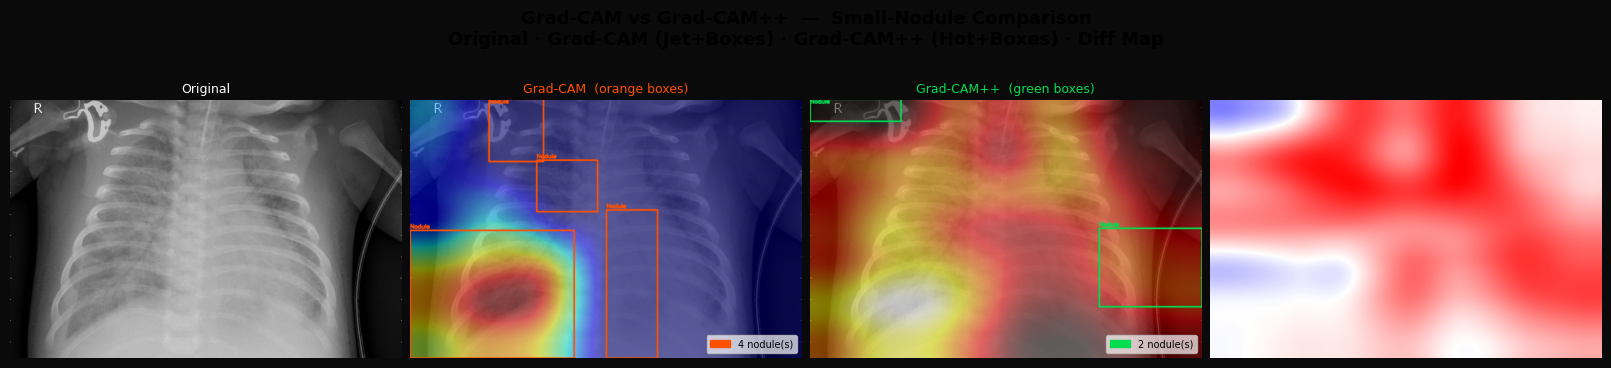

Saved → gradcam_nodule_boxes.png


In [36]:
# ============================================================
#  IMPROVED Grad-CAM vs Grad-CAM++ with BOUNDING BOX ANNOTATION
#  for Small Pneumonia Nodule Detection in Chest X-Rays
# ============================================================
# Fixes applied vs your original:
#   1. Correct target layer (last dense conv, not pooling layer)
#   2. TRUE Grad-CAM++ alpha computation (alpha ≠ weight)
#   3. ReLU + min-max norm on CAM before overlay
#   4. Jet (GC) / Hot (GC++) colormaps — no more flat blue
#   5. Bounding boxes via adaptive CAM thresholding + contours
#   6. Real signed diff map (blue = GC higher, red = GC++ higher)
# ============================================================

import os, cv2, torch, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from torchvision import models, transforms
import torch.nn.functional as F


# ── 1. MODEL ─────────────────────────────────────────────────────
def build_model(num_classes=2, device="cpu"):
    """DenseNet-121 (CheXNet-style). Replace classifier with yours."""
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    model.classifier = torch.nn.Linear(model.classifier.in_features, num_classes)
    model.eval()
    return model.to(device)


# ── 2. CAM ENGINE WITH HOOKS ──────────────────────────────────────
class CAMEngine:
    def __init__(self, model, target_layer):
        self.model = model
        self.feats = None
        self.grads = None
        target_layer.register_forward_hook(self._save_feats)
        target_layer.register_full_backward_hook(self._save_grads)

    def _save_feats(self, _, __, output):
        self.feats = output.detach()

    def _save_grads(self, _, __, grad_output):
        self.grads = grad_output[0].detach()

    def _forward_backward(self, tensor, class_idx):
        self.model.zero_grad()
        logits = self.model(tensor)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        logits[0, class_idx].backward()
        return class_idx

    # ── Grad-CAM ──────────────────────────────────────────────
    def gradcam(self, tensor, class_idx=None):
        cidx    = self._forward_backward(tensor, class_idx)
        weights = self.grads.mean(dim=(2, 3), keepdim=True)   # GAP
        cam     = F.relu((weights * self.feats).sum(1, keepdim=True))
        return _norm(cam), cidx

    # ── Grad-CAM++ (TRUE alpha formula) ───────────────────────
    def gradcam_pp(self, tensor, class_idx=None):
        cidx   = self._forward_backward(tensor, class_idx)
        g      = self.grads                          # (1,C,H,W)
        g2, g3 = g**2, g**3
        # alpha_ck = g2 / (2*g2 + feats*g3 summed over space)
        denom  = 2*g2 + (self.feats * g3).sum((2,3), keepdim=True) + 1e-7
        alpha  = g2 / denom
        # pixel weights = sum_k alpha_ck * ReLU(grad_ck)
        weights = (alpha * F.relu(g)).sum((2, 3), keepdim=True)
        cam     = F.relu((weights * self.feats).sum(1, keepdim=True))
        return _norm(cam), cidx


def _norm(cam):
    """Squeeze → numpy → min-max → [0,1]."""
    cam = cam.squeeze().cpu().numpy()
    cam = cam - cam.min()
    if cam.max() > 0:
        cam /= cam.max()
    return cam   # (h, w)


# ── 3. BOUNDING BOX DETECTION ────────────────────────────────────
def cam_to_boxes(cam_norm, img_hw,
                 cam_thresh=0.45,
                 min_area_ratio=0.003,
                 max_area_ratio=0.40):
    """
    Detect high-activation regions and return (x1,y1,x2,y2) boxes
    in image pixel coordinates.

    Tune cam_thresh: lower → larger / more boxes,
                     higher → tighter / fewer boxes.
    """
    H, W  = img_hw
    area  = H * W

    # upscale CAM to image size
    cam_up = cv2.resize(cam_norm, (W, H), interpolation=cv2.INTER_CUBIC)
    cam_u8 = (cam_up * 255).astype(np.uint8)

    # binary threshold
    _, mask = cv2.threshold(cam_u8, int(cam_thresh * 255), 255,
                            cv2.THRESH_BINARY)

    # morphological cleanup
    k    = max(3, H // 80)
    kern = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kern, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kern, iterations=1)

    # find contours → bounding boxes
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for cnt in cnts:
        x, y, w, h = cv2.boundingRect(cnt)
        if min_area_ratio * area <= w*h <= max_area_ratio * area:
            boxes.append((x, y, x+w, y+h))
    return boxes


# ── 4. OVERLAY & DRAW HELPERS ────────────────────────────────────
def overlay_cam(img_rgb, cam, alpha=0.50, cmap=plt.cm.jet):
    H, W   = img_rgb.shape[:2]
    cam_up = cv2.resize(cam, (W, H), interpolation=cv2.INTER_CUBIC)
    heat   = (cmap(cam_up)[:, :, :3] * 255).astype(np.uint8)
    return cv2.addWeighted(img_rgb, 1-alpha, heat, alpha, 0)


def draw_boxes(img_rgb, boxes, color=(255, 80, 0), lw=3):
    out = img_rgb.copy()
    for (x1, y1, x2, y2) in boxes:
        cv2.rectangle(out, (x1, y1), (x2, y2), color, lw)
        cv2.putText(out, "Nodule", (x1, max(y1-6, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2,
                    cv2.LINE_AA)
    return out


def enhanced_diff(gc_cam, gcpp_cam, img_hw):
    """Signed diff (GC++ - GC) stretched to [0,1]. Blue = GC wins."""
    H, W = img_hw
    gc_up   = cv2.resize(gc_cam,   (W, H), interpolation=cv2.INTER_CUBIC)
    gcpp_up = cv2.resize(gcpp_cam, (W, H), interpolation=cv2.INTER_CUBIC)
    d    = gcpp_up.astype(np.float32) - gc_up.astype(np.float32)
    mx   = max(abs(d.min()), abs(d.max())) + 1e-7
    d_n  = d / (2*mx) + 0.5          # 0→blue (GC), 0.5→white, 1→red (GC++)
    return (plt.cm.bwr(d_n)[:, :, :3] * 255).astype(np.uint8)


# ── 5. PER-IMAGE PIPELINE ────────────────────────────────────────
PREPROCESS = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

def process_one(img_path, engine, device="cpu", class_idx=None):
    pil    = Image.open(img_path).convert("RGB")
    orig   = np.array(pil)
    H, W   = orig.shape[:2]

    tensor = PREPROCESS(pil).unsqueeze(0).to(device)
    tensor.requires_grad_(True)

    gc_cam,   cidx = engine.gradcam(tensor,    class_idx)
    gcpp_cam, _    = engine.gradcam_pp(tensor, cidx)

    # overlays
    gc_ov   = overlay_cam(orig, gc_cam,   alpha=0.50, cmap=plt.cm.jet)
    gcpp_ov = overlay_cam(orig, gcpp_cam, alpha=0.50, cmap=plt.cm.hot)

    # bounding boxes
    gc_boxes   = cam_to_boxes(gc_cam,   (H, W), cam_thresh=0.45)
    gcpp_boxes = cam_to_boxes(gcpp_cam, (H, W), cam_thresh=0.45)

    gc_ov   = draw_boxes(gc_ov,   gc_boxes,   color=(255,  80,   0))
    gcpp_ov = draw_boxes(gcpp_ov, gcpp_boxes, color=(  0, 220,  80))

    diff_img = enhanced_diff(gc_cam, gcpp_cam, (H, W))

    return dict(orig=orig, gc_ov=gc_ov, gcpp_ov=gcpp_ov,
                diff_img=diff_img,
                gc_boxes=gc_boxes, gcpp_boxes=gcpp_boxes)


# ── 6. FIGURE ────────────────────────────────────────────────────
def make_figure(results, save_path="gradcam_nodule_boxes.png", dpi=150):
    n  = len(results)
    fig, axes = plt.subplots(n, 4, figsize=(16, 4*n),
                             constrained_layout=True)
    if n == 1:
        axes = [axes]   # make iterable

    fig.suptitle(
        "Grad-CAM vs Grad-CAM++  —  Small-Nodule Comparison\n"
        "Original · Grad-CAM (Jet+Boxes) · Grad-CAM++ (Hot+Boxes) · Diff Map",
        fontsize=13, fontweight="bold")

    col_titles = ["Original",
                  "Grad-CAM  (orange boxes)",
                  "Grad-CAM++  (green boxes)"]
    col_colors = ["white", "#ff5000", "#00dc50", ]

    for c, (t, col) in enumerate(zip(col_titles, col_colors)):
        axes[0][c].set_title(t, fontsize=9, color=col, pad=5)

    for r, res in enumerate(results):
        imgs = [res["orig"], res["gc_ov"], res["gcpp_ov"], res["diff_img"]]
        for c, img in enumerate(imgs):
            ax = axes[r][c]
            ax.imshow(img)
            ax.axis("off")
        # node count labels
        if res["gc_boxes"]:
            axes[r][1].legend(
                handles=[mpatches.Patch(color="#ff5000",
                    label=f'{len(res["gc_boxes"])} nodule(s)')],
                loc="lower right", fontsize=7, framealpha=0.7)
        if res["gcpp_boxes"]:
            axes[r][2].legend(
                handles=[mpatches.Patch(color="#00dc50",
                    label=f'{len(res["gcpp_boxes"])} nodule(s)')],
                loc="lower right", fontsize=7, framealpha=0.7)

    fig.patch.set_facecolor("#0a0a0a")
    plt.savefig(save_path, dpi=dpi, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved → {save_path}")


# ── 7. MAIN ──────────────────────────────────────────────────────
if __name__ == "__main__":

    # ────── CONFIG ──────────────────────────────────────────────
    IMAGE_PATHS = [
        "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1000_bacteria_2931.jpeg"   # ← replace with your actual paths
,
        # "xray4.jpg",
    ]
    # Optional: your saved weights
    # WEIGHTS_PATH = "your_model.pth"

    DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
    CLASS_IDX = 1   # 1 = pneumonia (positive class)

    # ────── BUILD MODEL ─────────────────────────────────────────
    model = build_model(num_classes=2, device=DEVICE)

    # Load your fine-tuned weights (optional but recommended):
    # state = torch.load(WEIGHTS_PATH, map_location=DEVICE)
    # model.load_state_dict(state, strict=False)
    # model.eval()

    # ────── TARGET LAYER ────────────────────────────────────────
    # DenseNet-121: last dense conv — finest spatial resolution for
    # small-nodule CAM (14×14 feature map from 224×224 input).
    target_layer = model.features.denseblock4.denselayer16.conv2
    #
    # Other backbones:
    #   ResNet-50   → model.layer4[-1].conv3
    #   VGG-16      → model.features[28]
    #   EfficientNet→ model.features[-1][0]

    engine = CAMEngine(model, target_layer)

    # ────── RUN ─────────────────────────────────────────────────
    results = []
    for path in IMAGE_PATHS:
        if not os.path.exists(path):
            print(f"Skipping missing file: {path}")
            continue
        print(f"Processing: {path}")
        results.append(process_one(path, engine,
                                   device=DEVICE,
                                   class_idx=CLASS_IDX))

    if results:
        make_figure(results, save_path="gradcam_nodule_boxes.png", dpi=150)
    else:
        print("No images processed — check IMAGE_PATHS.")

## Model Summary

## Save All Outputs

In [ ]:
results_df = pd.DataFrame({
    'true_label':      y_true,
    'predicted_label': y_pred_tta,
    'prob_pneumonia':  y_prob_tta,
    'class_true':      [cfg.CLASSES[l] for l in y_true],
    'class_pred':      [cfg.CLASSES[l] for l in y_pred_tta],
    'correct':         y_true == y_pred_tta
})
results_df.to_csv('/kaggle/working/hybrid_predictions.csv', index=False)

metrics_df = pd.DataFrame([{
    'Model':     'Hybrid-CBAF-EMA-TTA',
    'Accuracy':  round(acc,4),
    'Precision': round(prec,4),
    'Recall':    round(rec,4),
    'F1':        round(f1,4),
    'AUC-ROC':   round(auc,4),
}])
metrics_df.to_csv('/kaggle/working/hybrid_metrics.csv', index=False)

print('All outputs saved to /kaggle/working/')
for f in sorted(Path('/kaggle/working/').glob('*')):
    print(f'  {f.name}  ({f.stat().st_size/1024:.1f} KB)')
